In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [ ]:
data_manager = DataManager()
dataset_name = "mnist"

empty_model = initialize_resnet18(pretrained=False)
device = get_device()

MNIST_MODEL_DIR = Paths().MODEL_DIR / f"resnet18_{dataset_name}.pth"
model = load_model_weights(empty_model, MNIST_MODEL_DIR, device)


class_names = data_manager.get_class_names(dataset_name=dataset_name)

test_data = data_manager.get_test_dataset(
    dataset_name=dataset_name,
    download=False,
)

sigma = 0.8

## Wybór badanych przykładów

In [3]:
max_examples_per_class = 10

clean_examples = {class_id: [] for class_id in range(len(class_names))}

for image, label in test_data:
    if len(clean_examples[label]) >= max_examples_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label].append(image)

    if all(
        len(clean_examples[class_id]) >= max_examples_per_class
        for class_id in clean_examples
    ):
        break

clean_examples_vis = {
    class_id: clean_examples[class_id][0] for class_id in clean_examples
}

## Konfiguracja IG

In [4]:
ig_explainer = IGExplainer(model=model, device=device)
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
)
ig_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=ig_explainer,
)

ig_classes = ig_experiment_vis.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = ig_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Czyste obrazy

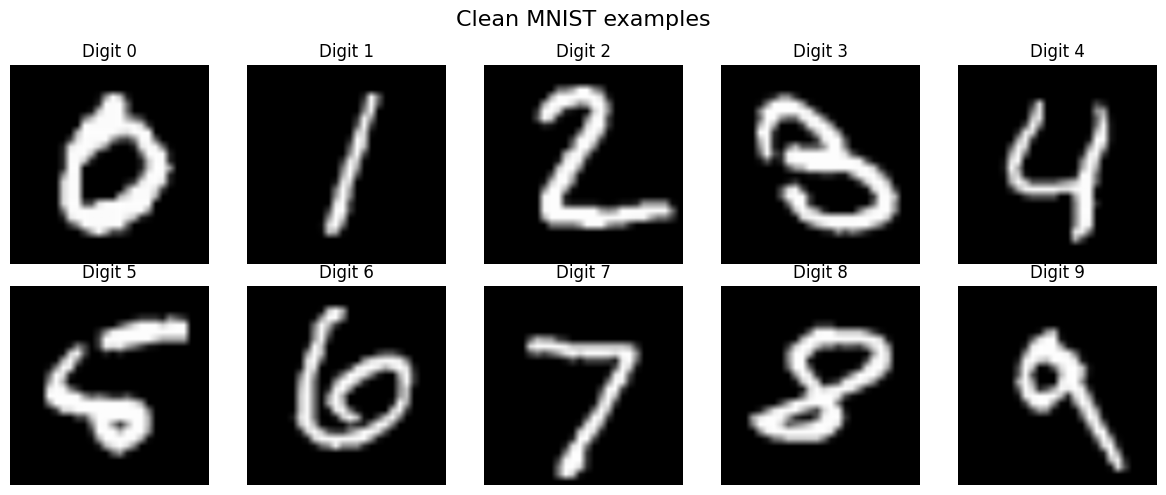

In [5]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaszumionych danych

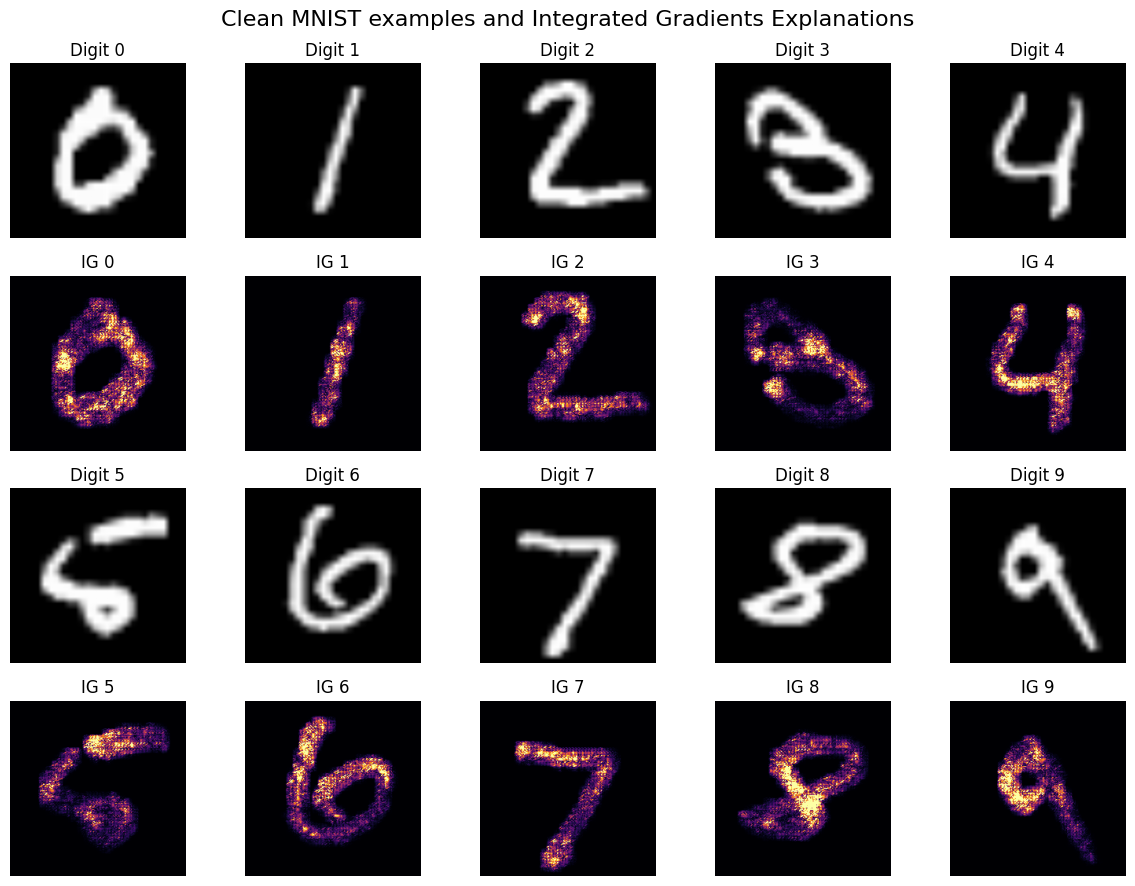

In [6]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Szum Gaussa - prezentacja

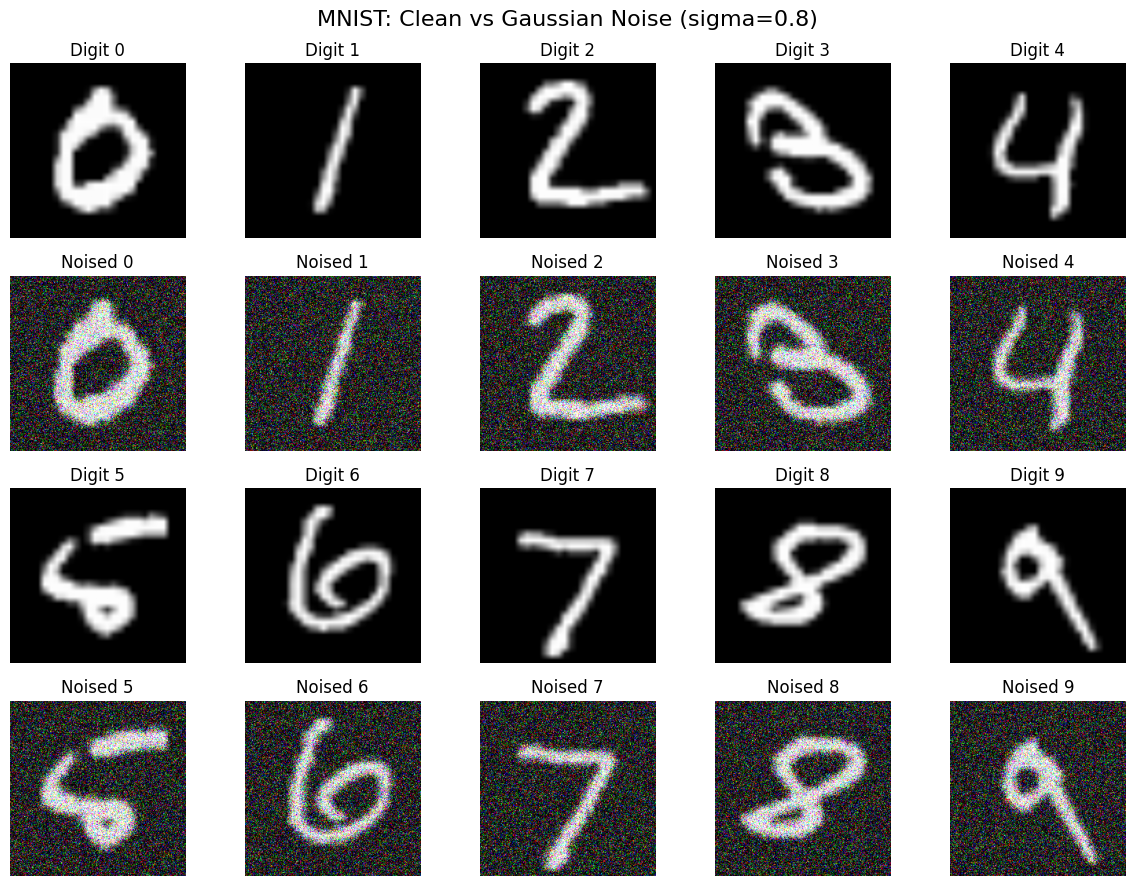

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = ig_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Noised {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG danych niezaszumionych oraz zaszumionych

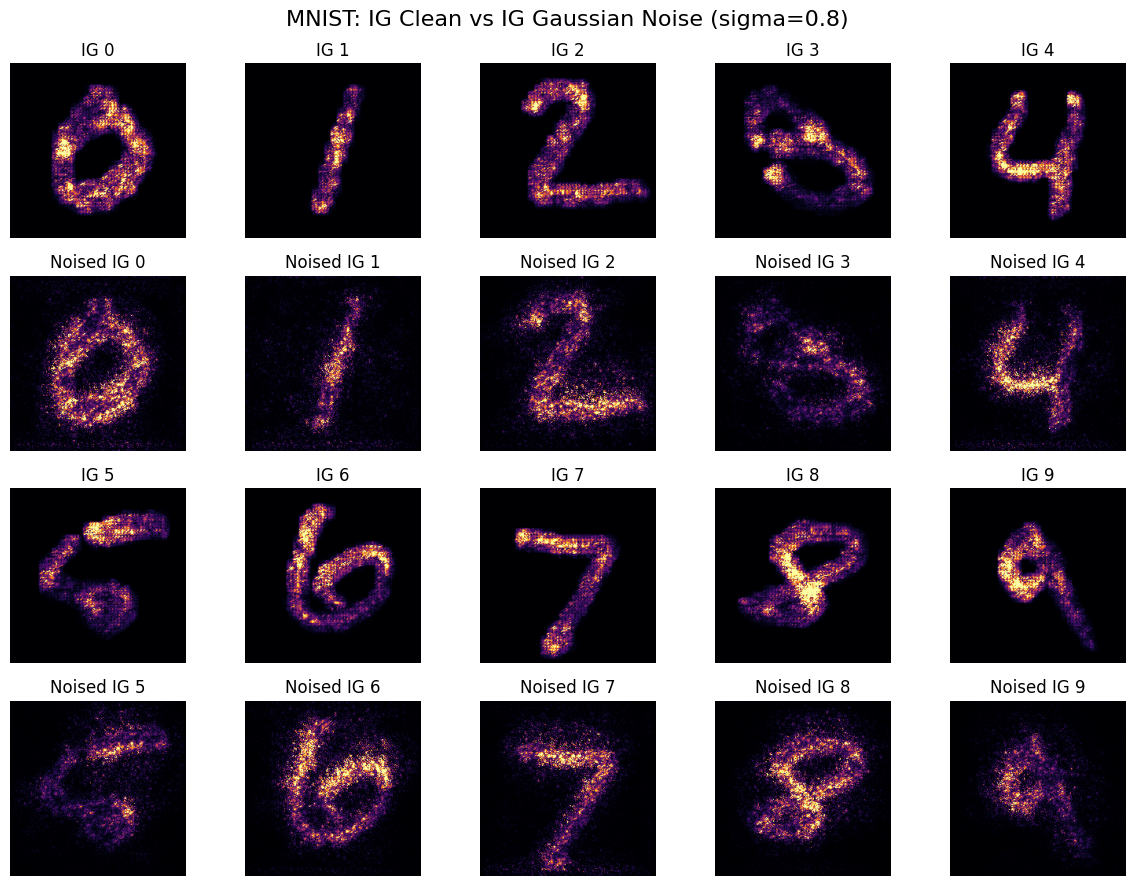

In [8]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = ig_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Noised IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (IG)

In [9]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=ig_experiment.experiment_config.gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.877,0.893,0.907,0.898,0.898,0.913,0.905,0.906,0.894,0.904
0.030,0.823,0.836,0.847,0.836,0.843,0.850,0.841,0.846,0.841,0.854
0.050,0.800,0.803,0.820,0.812,0.815,0.808,0.817,0.818,0.810,0.825
0.075,0.785,0.769,0.806,0.789,0.794,0.806,0.799,0.801,0.793,0.794
0.100,0.763,0.765,0.782,0.773,0.780,0.782,0.777,0.781,0.774,0.785
0.150,0.752,0.739,0.755,0.747,0.761,0.760,0.760,0.762,0.755,0.762
0.200,0.734,0.713,0.749,0.734,0.736,0.734,0.743,0.740,0.738,0.751
0.300,0.706,0.684,0.714,0.714,0.705,0.720,0.715,0.712,0.716,0.717
0.500,0.655,0.617,0.662,0.660,0.670,0.668,0.667,0.663,0.677,0.661


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.673,0.886,0.757,0.759,0.744,0.792,0.751,0.761,0.739,0.782
0.030,0.581,0.841,0.666,0.674,0.668,0.709,0.653,0.679,0.639,0.691
0.050,0.542,0.814,0.630,0.640,0.644,0.677,0.612,0.644,0.602,0.655
0.075,0.517,0.781,0.601,0.611,0.617,0.646,0.585,0.619,0.577,0.631
0.100,0.499,0.758,0.583,0.591,0.601,0.630,0.565,0.602,0.558,0.614
0.150,0.474,0.727,0.556,0.565,0.567,0.600,0.543,0.574,0.534,0.588
0.200,0.455,0.698,0.537,0.545,0.554,0.575,0.527,0.546,0.519,0.574
0.300,0.426,0.647,0.507,0.521,0.523,0.535,0.493,0.515,0.492,0.541
0.500,0.372,0.557,0.456,0.462,0.480,0.483,0.449,0.457,0.456,0.490


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,0.899,0.027,0.764,0.078
1,0.030,0.842,0.022,0.680,0.086
2,0.050,0.813,0.022,0.646,0.088
3,0.075,0.794,0.023,0.619,0.087
4,0.100,0.776,0.021,0.600,0.084
5,0.150,0.755,0.021,0.573,0.082
6,0.200,0.737,0.021,0.553,0.078
7,0.300,0.710,0.020,0.520,0.074
8,0.500,0.660,0.027,0.466,0.066
9,0.800,0.598,0.034,0.400,0.058


## Deletion AUC (IG)

In [10]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=ig_experiment.experiment_config.gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.334,0.808,0.441,0.227,0.377,0.413,0.701,0.317,0.423,0.129
0.030,0.302,0.787,0.389,0.166,0.319,0.398,0.710,0.257,0.398,0.129
0.050,0.277,0.775,0.351,0.106,0.205,0.300,0.671,0.164,0.351,0.105
0.075,0.206,0.807,0.282,0.067,0.126,0.222,0.667,0.114,0.319,0.079
0.100,0.161,0.768,0.191,0.053,0.080,0.157,0.616,0.075,0.273,0.073
0.150,0.120,0.770,0.126,0.037,0.053,0.087,0.482,0.042,0.240,0.058
0.200,0.102,0.791,0.128,0.031,0.040,0.062,0.313,0.042,0.205,0.047
0.300,0.067,0.692,0.091,0.026,0.034,0.044,0.254,0.029,0.134,0.041
0.500,0.057,0.660,0.102,0.020,0.032,0.034,0.157,0.024,0.131,0.036


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.279,0.236,0.417,0.275,0.997,0.997,0
1,0.030,0.279,0.236,0.386,0.274,0.997,0.996,0
2,0.050,0.279,0.236,0.330,0.276,0.997,0.996,0
3,0.075,0.279,0.236,0.289,0.279,0.997,0.994,0
4,0.100,0.279,0.236,0.245,0.267,0.997,0.991,0
5,0.150,0.279,0.236,0.201,0.253,0.997,0.986,1
6,0.200,0.279,0.236,0.176,0.244,0.997,0.981,1
7,0.300,0.279,0.236,0.141,0.211,0.997,0.961,2
8,0.500,0.279,0.236,0.125,0.197,0.997,0.905,8
9,0.800,0.279,0.236,0.100,0.164,0.997,0.712,22


## Konfiguracja Occlusion

In [11]:
occ_explainer = OcclusionExplainer(model=model, device=device, dataset=dataset_name)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
)
occ_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=occ_explainer,
)

occ_classes = occ_experiment_vis.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = occ_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezaszumionych danych

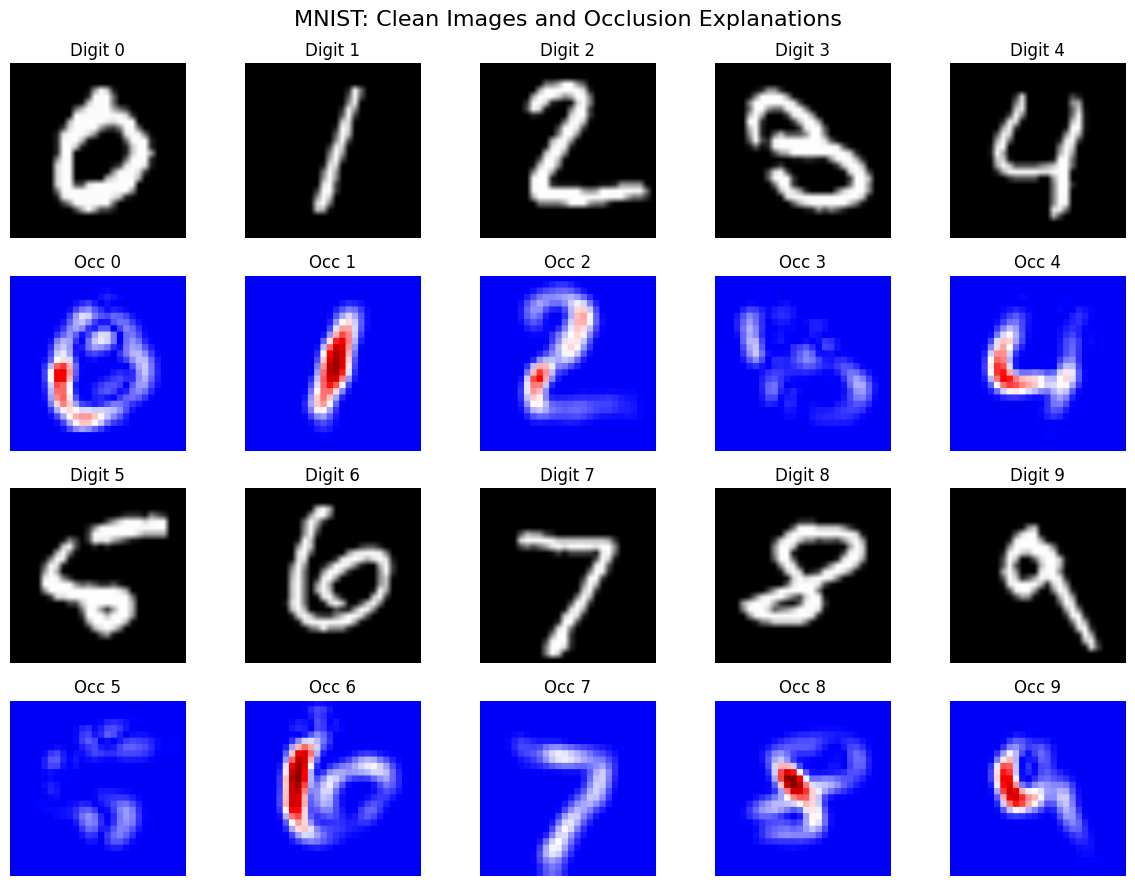

In [12]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    attr_occ = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Occlusion danych niezaszumionych oraz zaszumionych

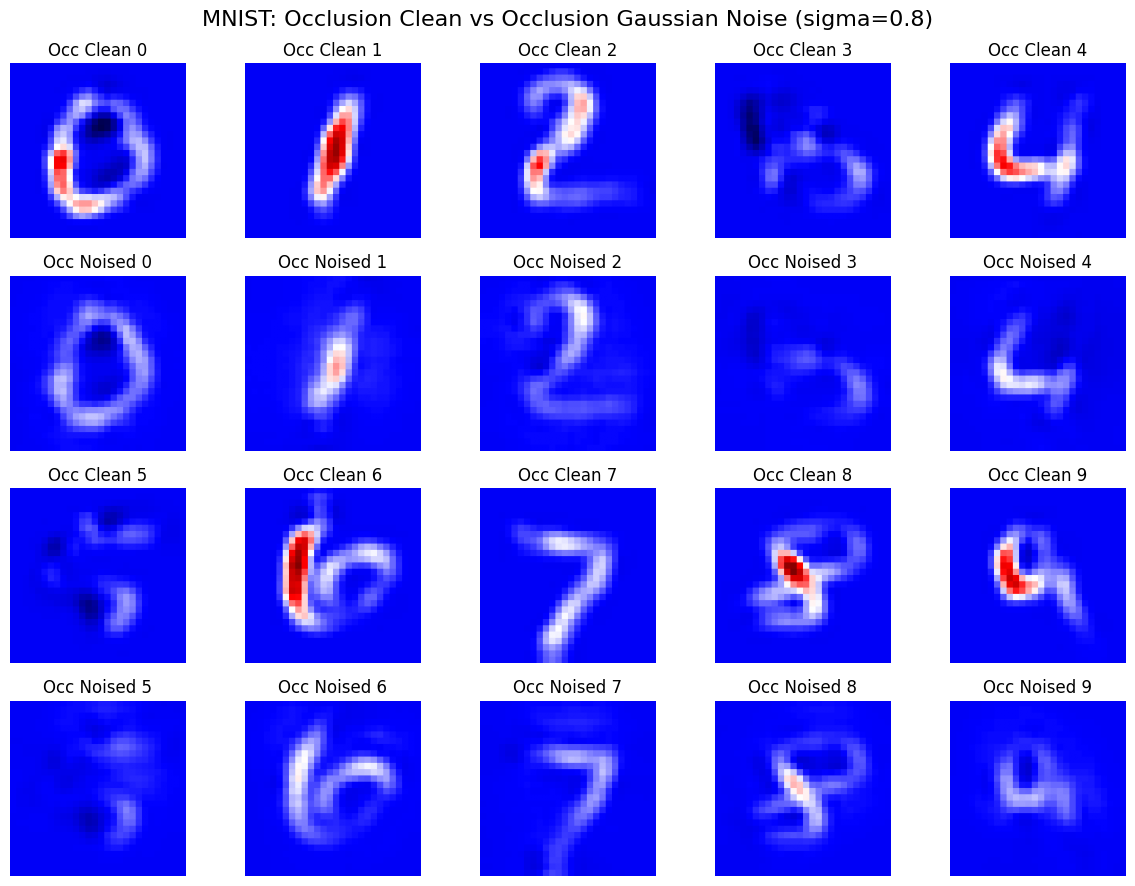

In [13]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Occlusion Clean vs Occlusion Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = occ_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    attr_occ_clean = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Noised {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [ ]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=occ_experiment.experiment_config.gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075


## Deletion AUC (Occlusion)

In [ ]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=occ_experiment.experiment_config.gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.107,0.981,0.124,0.068,0.095,0.184,0.085,0.157,0.096,0.056
0.030,0.107,0.981,0.120,0.066,0.092,0.183,0.086,0.155,0.094,0.056
0.050,0.107,0.986,0.122,0.066,0.091,0.180,0.086,0.151,0.096,0.057
0.075,0.107,0.984,0.119,0.064,0.089,0.160,0.085,0.146,0.093,0.059
0.100,0.106,0.985,0.115,0.060,0.087,0.157,0.088,0.147,0.097,0.058
0.150,0.112,0.985,0.112,0.058,0.083,0.146,0.091,0.139,0.101,0.058
0.200,0.114,0.982,0.106,0.057,0.075,0.139,0.090,0.134,0.100,0.056
0.300,0.125,0.983,0.103,0.052,0.075,0.126,0.097,0.125,0.098,0.050
0.500,0.147,0.980,0.080,0.044,0.094,0.097,0.100,0.110,0.094,0.042


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.194,0.27,0.195,0.271,0.999,0.999,0
1,0.030,0.194,0.27,0.194,0.271,0.999,0.999,0
2,0.050,0.194,0.27,0.194,0.273,0.999,0.999,0
3,0.075,0.194,0.27,0.191,0.271,0.999,0.999,0
4,0.100,0.194,0.27,0.190,0.271,0.999,0.999,0
5,0.150,0.194,0.27,0.188,0.272,0.999,0.999,0
6,0.200,0.194,0.27,0.185,0.271,0.999,0.998,0
7,0.300,0.194,0.27,0.183,0.272,0.999,0.997,0
8,0.500,0.194,0.27,0.179,0.274,0.999,0.989,0
9,0.800,0.194,0.27,0.180,0.289,0.999,0.915,5
